In [5]:
import sqlite3

# Connect to (or create) the database
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

# Step 1: Create the 'sales' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

# Step 2: Insert some dummy sales data
sample_data = [
    ('Widget', 10, 2.5),
    ('Widget', 5, 2.5),
    ('Gadget', 8, 3.0),
    ('Gizmo', 15, 1.5),
    ('Gadget', 2, 3.0),
    ('Gizmo', 5, 1.5)
]
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)

# Commit and close
conn.commit()
conn.close()

Sales Summary:
  product  total_qty  revenue
0  Gadget         10     30.0
1   Gizmo         20     30.0
2  Widget         15     37.5


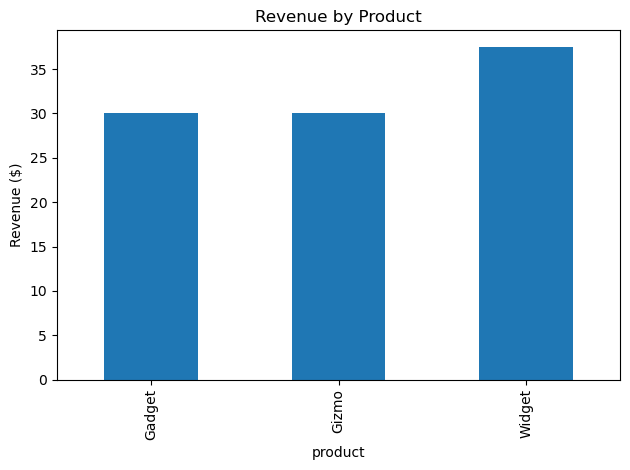

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('sales_data.db')

# Define SQL query
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Load SQL query result into a pandas DataFrame
df = pd.read_sql_query(query, conn)

# Print the result
print("Sales Summary:")
print(df)

# Plot a bar chart for revenue by product
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False)
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('sales_chart.png')  # Optional: Save chart as PNG_
